In [2]:
import sys
print(sys.executable)

/home/atul-b-ghadge/jupyter_env/bin/python3


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, f_regression
import joblib

In [2]:
RANDOM_STATE = 42

In [3]:
df = pd.read_csv('dubai.csv')
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())


df.sample(5)

Shape: (5058, 12)

Columns: ['title', 'displayAddress', 'bathrooms', 'bedrooms', 'addedOn', 'type', 'price', 'verified', 'priceDuration', 'sizeMin', 'furnishing', 'description']


,title,displayAddress,bathrooms,bedrooms,addedOn,type,price,verified,priceDuration,sizeMin,furnishing,description
4658,Spacious Townhouse | With Maid Room | Premium ...,"MAG Eye, District 7, Mohammed Bin Rashid City,...",3,3,2024-07-01T11:45:09Z,Residential for Sale,3400000,True,sell,2283 sqft,NO,Features and Amenities:\n- 3 Bedrooms\n- 3 Bat...
4022,⚡HOT PRICE ⚡2+ Maid ⚡Great Investment,"Yas Park Gate, Yas Island, Abu Dhabi",3,2,2024-07-22T14:26:07Z,Residential for Sale,1893000,False,sell,1883 sqft,NO,Yas Park Gate by Aldar Properties is a new res...
115,Spacious 1 BR | Middle Floor | Beachfront,"La Vie, Jumeirah Beach Residence, Dubai",1,1,2024-06-21T14:03:02Z,Residential for Sale,3000000,True,sell,920 sqft,NO,Property Features:\n* 1 Bedroom\n* 1 Bathroom\...
4368,Best Deal in the Market | Spacious Studio,"Blue Waves Tower, Dubai Residence Complex, Dubai",1,studio,2024-07-23T13:24:19Z,Residential for Sale,505000,True,sell,439 sqft,NO,Recently Handover Spacious Studio located at B...
2573,380KDP -Freehold -Private Island - ROI 300K Ye...,"AlThuraya Island, Ajmal Makan City, Al Hamriya...",7,5,2024-08-10T13:08:38Z,Residential for Sale,3887000,False,sell,6596 sqft,NO,- Natural Island\n- Private Beach\n- Waterfron...


In [4]:
print(df.info())
print('\nMissing values per column:\n', df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           5058 non-null   object
 1   displayAddress  5058 non-null   object
 2   bathrooms       4938 non-null   object
 3   bedrooms        4935 non-null   object
 4   addedOn         5058 non-null   object
 5   type            5058 non-null   object
 6   price           5058 non-null   int64 
 7   verified        5058 non-null   bool  
 8   priceDuration   5058 non-null   object
 9   sizeMin         5058 non-null   object
 10  furnishing      5056 non-null   object
 11  description     5057 non-null   object
dtypes: bool(1), int64(1), object(10)
memory usage: 439.7+ KB
None

Missing values per column:
 title               0
displayAddress      0
bathrooms         120
bedrooms          123
addedOn             0
type                0
price               0
verified            0
price

In [5]:
print('\nPrice summary:')
print(df['price'].describe())


Price summary:
count    5.058000e+03
mean     5.050924e+06
std      1.000928e+07
min      1.000000e+05
25%      1.200000e+06
50%      2.350000e+06
75%      4.499375e+06
max      1.990000e+08
Name: price, dtype: float64


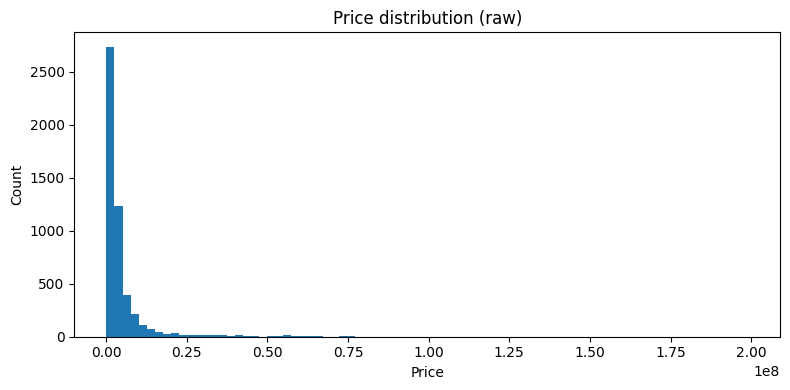

In [6]:
plt.figure(figsize=(8,4))
plt.hist(df['price'].dropna(), bins=80)
plt.title('Price distribution (raw)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [7]:
import math
import re
import numpy as np
import pandas as pd

def parse_sqft(val):
    """
    Cleans size strings like '1,323 sqft' into numeric values.
    Returns np.nan if parsing fails.
    """
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    
    s = str(val).lower().replace(',', '')
    m = re.search(r"([0-9]+(?:\.[0-9]+)?)", s)
    if m:
        try:
            return float(m.group(1))
        except:
            return np.nan
    return np.nan


def clean_price(x):
    """
    Cleans price values, extracting numbers from strings like '2,500,000 AED'.
    """
    if pd.isna(x):
        return np.nan
    try:
        return float(x)
    except:
        s = str(x).replace(',', '')
        m = re.search(r"([0-9]+(?:\.[0-9]+)?)", s)
        if m:
            return float(m.group(1))
        return np.nan


def text_signals(title, description):
    """
    Extracts simple NLP-based features from title + description.
    """
    t = str(title) if not pd.isna(title) else ''
    d = str(description) if not pd.isna(description) else ''
    combined = (t + ' ' + d).lower()
    return {
        'title_len': len(t),
        'desc_len': len(d),
        'title_words': len(t.split()),
        'desc_words': len(d.split()),
        'has_sea': int('sea' in combined or 'sea view' in combined),
        'has_view': int('view' in combined),
        'has_new': int('new' in combined or 'brand new' in combined),
        'has_roi': int('roi' in combined),
        'has_furnished': int('furnish' in combined),
    }


In [8]:
data = df.copy()


# clean numeric columns
data['price'] = data['price'].apply(clean_price)


# bedrooms / bathrooms sometimes are floats but if string with '+' or values, attempt safe conversion
for c in ['bedrooms', 'bathrooms']:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors='coerce')


# parse sizeMin
if 'sizeMin' in data.columns:
    data['size_min_clean'] = data['sizeMin'].apply(parse_sqft)
else:
    data['size_min_clean'] = np.nan


# addedOn -> datetime
if 'addedOn' in data.columns:
    data['addedOn_dt'] = pd.to_datetime(data['addedOn'], errors='coerce')
    data['addedOn_year'] = data['addedOn_dt'].dt.year
    data['addedOn_month'] = data['addedOn_dt'].dt.month
else:
    data['addedOn_dt'] = pd.NaT
    data['addedOn_year'] = np.nan
    data['addedOn_month'] = np.nan


# light text signals
text_feats = pd.DataFrame([text_signals(r['title'], r['description']) for _, r in data.iterrows()])
text_feats.index = data.index


# attach
data = pd.concat([data, text_feats], axis=1)


# price per sqft (use size if > 0)
data['price_per_sqft'] = data.apply(lambda r: (r['price'] / r['size_min_clean']) if (pd.notna(r['price']) and pd.notna(r['size_min_clean']) and r['size_min_clean']>0) else np.nan, axis=1)


# show cleaned sample
cols_show = ['price', 'bedrooms', 'bathrooms', 'sizeMin', 'size_min_clean', 'price_per_sqft', 'title_len', 'desc_len']
cols_show = [c for c in cols_show if c in data.columns]


data[cols_show].head(8)

,price,bedrooms,bathrooms,sizeMin,size_min_clean,price_per_sqft,title_len,desc_len
0,2500000.0,2.0,3.0,1323 sqft,1323.0,1889.644747,35,1272
1,7200000.0,2.0,3.0,1410 sqft,1410.0,5106.382979,48,1140
2,3600000.0,4.0,3.0,2324 sqft,2324.0,1549.053356,40,1102
3,2999999.0,2.0,3.0,1647 sqft,1647.0,1821.493018,40,1025
4,2449999.0,3.0,3.0,2105 sqft,2105.0,1163.895012,38,1026
5,25000000.0,5.0,7.0,7059 sqft,7059.0,3541.578127,40,1072
6,4980000.0,2.0,3.0,1095 sqft,1095.0,4547.945205,48,1286
7,2800000.0,3.0,4.0,1991 sqft,1991.0,1406.328478,50,1716


Missing values now:
price               0
bedrooms          679
bathrooms         233
size_min_clean      0
price_per_sqft      0
dtype: int64


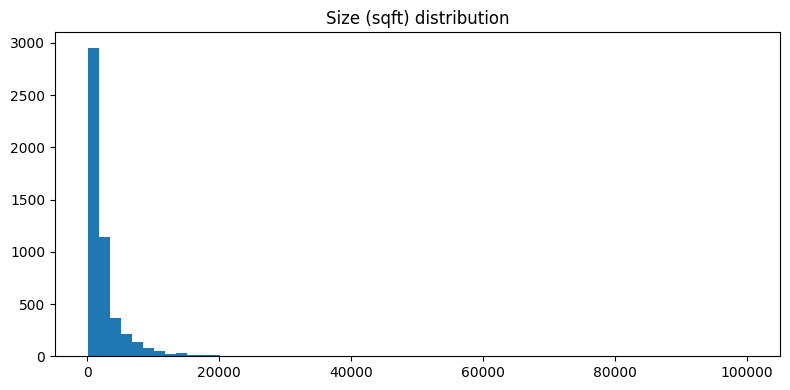

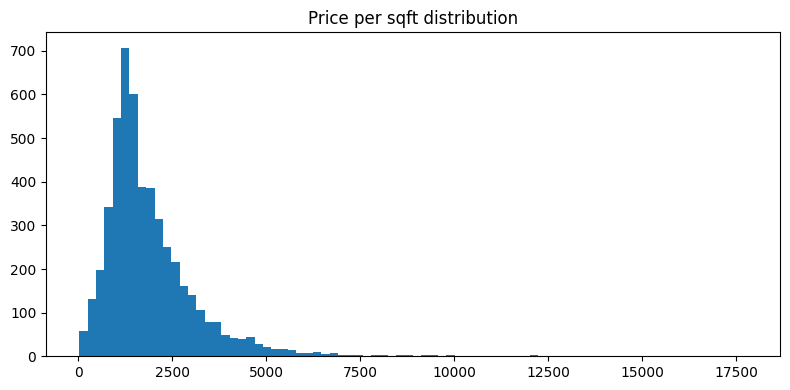

In [9]:
print('Missing values now:')
print(data[['price','bedrooms','bathrooms','size_min_clean','price_per_sqft']].isna().sum())


plt.figure(figsize=(8,4))
plt.hist(data['size_min_clean'].dropna(), bins=60)
plt.title('Size (sqft) distribution')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,4))
plt.hist(data['price_per_sqft'].dropna(), bins=80)
plt.title('Price per sqft distribution')
plt.tight_layout()
plt.show()

In [10]:
numeric_features = [c for c in ['bedrooms','bathrooms','size_min_clean','title_len','desc_len','price_per_sqft'] if c in data.columns]
cat_features = [c for c in ['displayAddress','type','furnishing','verified','priceDuration'] if c in data.columns]
text_feature = 'title' if 'title' in data.columns else None


print('Numeric features:', numeric_features)
print('Categorical features:', cat_features)
print('Text feature:', text_feature)


# Basic frequency for displayAddress
if 'displayAddress' in data.columns:
    top_addrs = data['displayAddress'].value_counts().nlargest(20).index.tolist()
    print('\nTop displayAddress examples:', top_addrs[:8])


# create a cleaned 'addr_top' column that keeps top N else 'other'
if 'displayAddress' in data.columns:
    data['displayAddress_top'] = data['displayAddress'].apply(lambda x: x if x in top_addrs else 'other')
# replace cat_features entry
    if 'displayAddress' in cat_features:
        cat_features = [c if c!='displayAddress' else 'displayAddress_top' for c in cat_features]


cat_features

Numeric features: ['bedrooms', 'bathrooms', 'size_min_clean', 'title_len', 'desc_len', 'price_per_sqft']
Categorical features: ['displayAddress', 'type', 'furnishing', 'verified', 'priceDuration']
Text feature: title

Top displayAddress examples: ['Hayyan, Sharjah', 'Verdana Residence, Dubai Investment Park (DIP), Dubai', 'Al Zaheya Gardens, Al Zahya, Ajman', 'Al Yasmeen 1, Al Yasmeen, Ajman', 'AZIZI Riviera, Meydan One, Meydan, Dubai', 'Faradis Tower, Al Mamzar - Sharjah, Sharjah', 'Saadiyat Lagoons, Saadiyat Island, Abu Dhabi', 'Bay Villas, Dubai Islands, Deira, Dubai']


['displayAddress_top', 'type', 'furnishing', 'verified', 'priceDuration']

In [11]:
data_model = data.copy()
# drop rows without price
data_model = data_model[pd.notna(data_model['price'])].reset_index(drop=True)


# create target transforms
data_model['log_price'] = np.log1p(data_model['price'])


# features we'll use in pipelines (excluding raw text for baseline)
FEATURES_BASE = numeric_features + cat_features
FEATURES_BASE = [f for f in FEATURES_BASE if f in data_model.columns]


print('Using baseline features:', FEATURES_BASE)


X = data_model[FEATURES_BASE]
y = data_model['log_price'] # training on log price


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('\nTrain shape:', X_train.shape, 'Test shape:', X_test.shape)

Using baseline features: ['bedrooms', 'bathrooms', 'size_min_clean', 'title_len', 'desc_len', 'price_per_sqft', 'displayAddress_top', 'type', 'furnishing', 'verified', 'priceDuration']

Train shape: (4046, 11) Test shape: (1012, 11)


In [12]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, cat_features)
], remainder='drop')

# Baseline pipeline
baseline_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit baseline
baseline_pipe.fit(X_train, y_train)

# Predict on test set (remember predictions are log_price)
y_pred_log = baseline_pipe.predict(X_test)

# Back-transform
y_test_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred_log)

# Metrics (price scale)
mae = mean_absolute_error(y_test_price, y_pred_price)
mse = mean_squared_error(y_test_price, y_pred_price)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_price, y_pred_price)

print('Baseline (LinearRegression) results on test set (price scale):')
print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")

# Also show metrics in log-space
mae_log = mean_absolute_error(y_test, y_pred_log)
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)
print('\nLog-space metrics:')
print(f"MAE (log): {mae_log:.4f}")
print(f"RMSE (log): {rmse_log:.4f}")

Baseline (LinearRegression) results on test set (price scale):
MAE: 2,552,272
RMSE: 17,625,090
R²: -2.0529

Log-space metrics:
MAE (log): 0.2958
RMSE (log): 0.4018


In [13]:
ridge_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(alpha=1.0, random_state=RANDOM_STATE))])
ridge_pipe.fit(X_train, y_train)
y_pred_log_ridge = ridge_pipe.predict(X_test)
y_pred_price_ridge = np.expm1(y_pred_log_ridge)


# RF pipeline (uses same preprocessor; beware of many one-hot features -> RF handles numeric arrays fine)
rf_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1, max_depth=12))])
rf_pipe.fit(X_train, y_train)
y_pred_log_rf = rf_pipe.predict(X_test)
y_pred_price_rf = np.expm1(y_pred_log_rf)


# Evaluate all three (price scale)
models_eval = {
'Linear': y_pred_price,
'Ridge': y_pred_price_ridge,
'RandomForest': y_pred_price_rf
}


for name, pred in models_eval.items():
    mae_m = mean_absolute_error(y_test_price, pred)
    rmse_m = np.sqrt(mean_squared_error(y_test_price, pred))
    r2_m = r2_score(y_test_price, pred)
    print(f"{name} -> MAE: {mae_m:,.0f} | RMSE: {rmse_m:,.0f} | R²: {r2_m:.4f}")


# Also compare log-space RMSE (useful for skewed targets)
for name, pred_log in [('Linear', y_pred_log), ('Ridge', y_pred_log_ridge), ('RandomForest', y_pred_log_rf)]:
    rmse_log_m = np.sqrt(mean_squared_error(y_test, pred_log))
    print(f"{name} RMSE (log-space): {rmse_log_m:.4f}")

Linear -> MAE: 2,552,272 | RMSE: 17,625,090 | R²: -2.0529
Ridge -> MAE: 2,556,047 | RMSE: 17,725,775 | R²: -2.0879
RandomForest -> MAE: 246,219 | RMSE: 1,596,982 | R²: 0.9749
Linear RMSE (log-space): 0.4018
Ridge RMSE (log-space): 0.4016
RandomForest RMSE (log-space): 0.0704


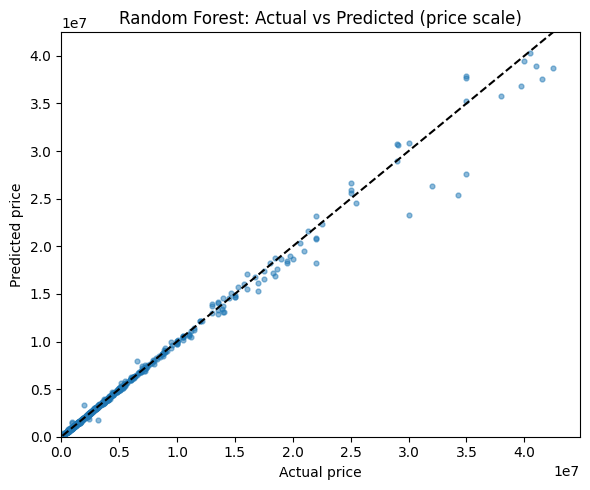

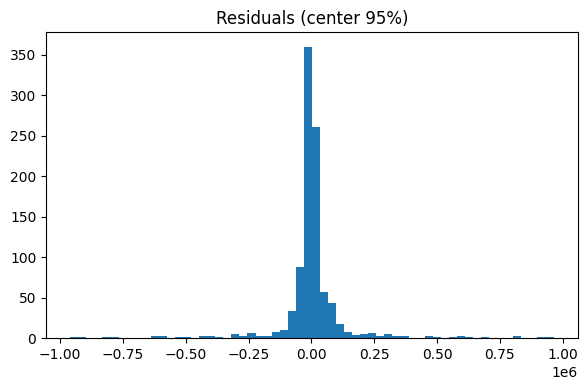

In [14]:
rf_preds = y_pred_price_rf


plt.figure(figsize=(6,5))
plt.scatter(y_test_price, rf_preds, alpha=0.5, s=12)
plt.plot([y_test_price.min(), y_test_price.max()], [y_test_price.min(), y_test_price.max()], '--', color='k')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Random Forest: Actual vs Predicted (price scale)')
plt.xlim(0, np.percentile(y_test_price, 98))
plt.ylim(0, np.percentile(rf_preds, 98))
plt.tight_layout()
plt.show()


# residuals
resid = y_test_price - rf_preds
plt.figure(figsize=(6,4))
plt.hist(resid[np.abs(resid) < np.percentile(np.abs(resid), 95)], bins=60)
plt.title('Residuals (center 95%)')
plt.tight_layout()
plt.show()


Top ridge coefficients (by absolute value):
displayAddress_top__Al Yasmeen 1, Al Yasmeen, Ajman                                      -0.758687
displayAddress_top__Al Zaheya Gardens, Al Zahya, Ajman                                   -0.737454
price_per_sqft                                                                            0.538290
displayAddress_top__Verdana Residence, Dubai Investment Park (DIP), Dubai                -0.504625
displayAddress_top__Harmony, Tilal Al Ghaf, Dubai                                         0.414789
displayAddress_top__Bay Villas, Dubai Islands, Deira, Dubai                               0.412495
displayAddress_top__Verdana 2, Dubai Investment Park (DIP), Dubai                        -0.401155
bathrooms                                                                                 0.392543
displayAddress_top__Saadiyat Lagoons, Saadiyat Island, Abu Dhabi                          0.389367
size_min_clean                                                  

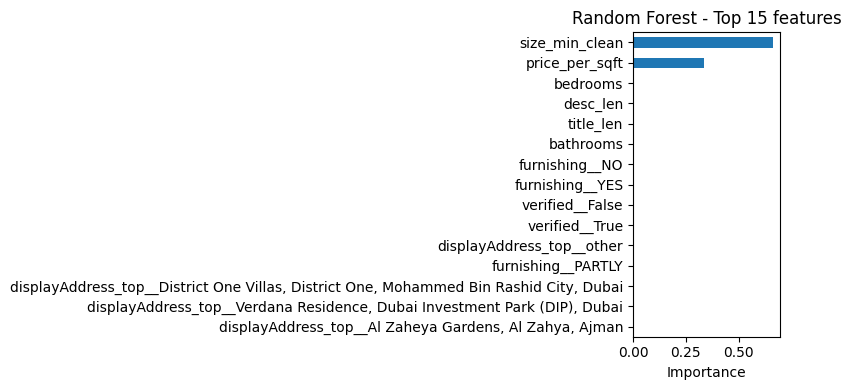


Running permutation importance (may take some time)

Top permutation importances:
size_min_clean                                                               1.352643e+00
price_per_sqft                                                               6.770723e-01
bedrooms                                                                     1.016265e-03
title_len                                                                    1.045240e-04
desc_len                                                                     5.259455e-05
furnishing__NO                                                               4.318453e-05
bathrooms                                                                    3.416239e-05
displayAddress_top__other                                                    4.709171e-06
furnishing__YES                                                              3.461498e-06
displayAddress_top__Verdana Residence, Dubai Investment Park (DIP), Dubai    3.447333e-06
furnishing__PARTL

In [15]:
num_features = numeric_features


# OneHotEncoder categories -> build names
ohe = ridge_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_cols = []
if isinstance(ohe, OneHotEncoder):
    cats = ridge_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].categories_
# careful: col order matches cat_features
    for i, cats_i in enumerate(cats):
        prefix = cat_features[i]
        cat_cols += [f"{prefix}__" + str(x) for x in cats_i]


feature_names = num_features + cat_cols
coeffs = ridge_pipe.named_steps['regressor'].coef_
coef_ser = pd.Series(coeffs, index=feature_names).sort_values(key=lambda s: np.abs(s), ascending=False)
print('\nTop ridge coefficients (by absolute value):')
print(coef_ser.head(20))


# %%
# Random Forest feature importances - we must get preprocessed feature matrix to map features
# Build a transformed training set to capture feature columns
X_train_trans = preprocessor.fit_transform(X_train)
# Build names for transformed columns (numeric + onehot)
transformed_names = []
# numeric names
transformed_names.extend(numeric_features)
# categorical onehot names
for i, feat in enumerate(cat_features):
    cats_i = preprocessor.named_transformers_['cat'].named_steps['onehot'].categories_[i]
    transformed_names.extend([f"{feat}__" + str(c) for c in cats_i])


if hasattr(rf_pipe.named_steps['regressor'], 'feature_importances_'):
    importances = rf_pipe.named_steps['regressor'].feature_importances_
    feat_imp = pd.Series(importances, index=transformed_names).sort_values(ascending=False)
    print('\nRandom Forest top features:')
    print(feat_imp.head(20))


plt.figure(figsize=(8,4))
feat_imp.head(15).sort_values().plot.barh()
plt.title('Random Forest - Top 15 features')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


# permutation importance (on test set, log-space predictor)
print('\nRunning permutation importance (may take some time)')
perm = permutation_importance(rf_pipe.named_steps['regressor'], preprocessor.transform(X_test), y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=transformed_names).sort_values(ascending=False)
print('\nTop permutation importances:')
print(perm_imp.head(15))

In [17]:
from sklearn.base import BaseEstimator, TransformerMixin

class ColumnExtractor(BaseEstimator, TransformerMixin):
    """Custom transformer to extract a single column as Series or array."""
    def __init__(self, column):
        self.column = column

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[self.column]

if text_feature is not None:
    tfidf = TfidfVectorizer(
        max_features=800, 
        ngram_range=(1, 2), 
        stop_words='english'
    )

    preprocessor_with_text = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, cat_features),
        ('title_tfidf', Pipeline([
            ('extract', ColumnExtractor(text_feature)),
            ('tfidf', tfidf)
        ]), [text_feature])  # ✅ FIXED
    ], remainder='drop')

    pipe_rf_text = Pipeline(steps=[
        ('preprocessor', preprocessor_with_text),
        ('regressor', RandomForestRegressor(
            n_estimators=120, 
            max_depth=12, 
            random_state=RANDOM_STATE, 
            n_jobs=-1
        ))
    ])

    # Full data with text feature included
    X_full = data_model[FEATURES_BASE + [text_feature]]
    X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
        X_full, y, test_size=0.2, random_state=RANDOM_STATE
    )

    pipe_rf_text.fit(X_train_full, y_train_full)

    # Predictions
    y_pred_log_rf_text = pipe_rf_text.predict(X_test_full)
    y_pred_price_rf_text = np.expm1(y_pred_log_rf_text)
    y_test_price_full = np.expm1(y_test_full)

    print('\nRandom Forest with TF-IDF on title:')
    print('MAE:', mean_absolute_error(y_test_price_full, y_pred_price_rf_text))
    print('RMSE:', np.sqrt(mean_squared_error(y_test_price_full, y_pred_price_rf_text)))
    print('R²:', r2_score(y_test_price_full, y_pred_price_rf_text))

    # Save model
    joblib.dump(pipe_rf_text, "rf_with_title_tfidf.joblib")
    print("✅ Model saved as rf_with_title_tfidf.joblib")



Random Forest with TF-IDF on title:
MAE: 257638.21525442184
RMSE: 1639338.1646458071
R²: 0.9735885727717049
✅ Model saved as rf_with_title_tfidf.joblib


In [18]:
sample = X_test_full.sample(5, random_state=42)
preds = pipe_rf_text.predict(sample)
pred_prices = np.expm1(preds)

print("Sample Predictions vs Actual:")
print(pd.DataFrame({
    "Predicted": pred_prices,
    "Actual": np.expm1(y_test_full.loc[sample.index])
}))


Sample Predictions vs Actual:
         Predicted      Actual
70    2.512568e+06   2593860.0
1448  3.757426e+06   3799999.0
4850  4.877936e+06   5100000.0
1200  2.234167e+06   2250000.0
287   5.098428e+07  53000000.0


In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe_rf_text, X_full, y, cv=5, scoring="r2", n_jobs=-1)
print("Cross-validation R² scores:", scores)
print("Average R²:", scores.mean())


Cross-validation R² scores: [0.99597241 0.99449747 0.99359458 0.99454778 0.99677366]
Average R²: 0.9950771793575498


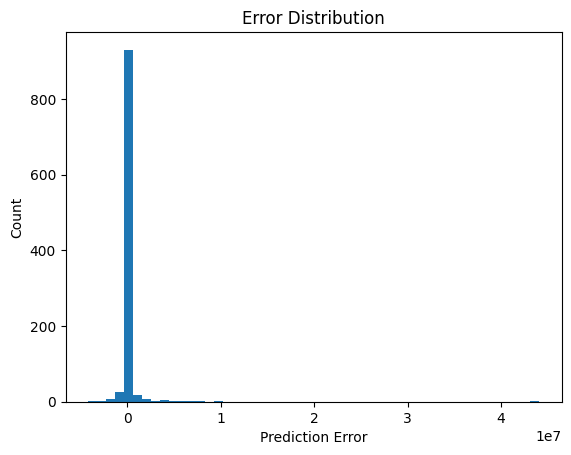

In [20]:
import matplotlib.pyplot as plt

errors = y_test_price_full - y_pred_price_rf_text
plt.hist(errors, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Error Distribution")
plt.show()


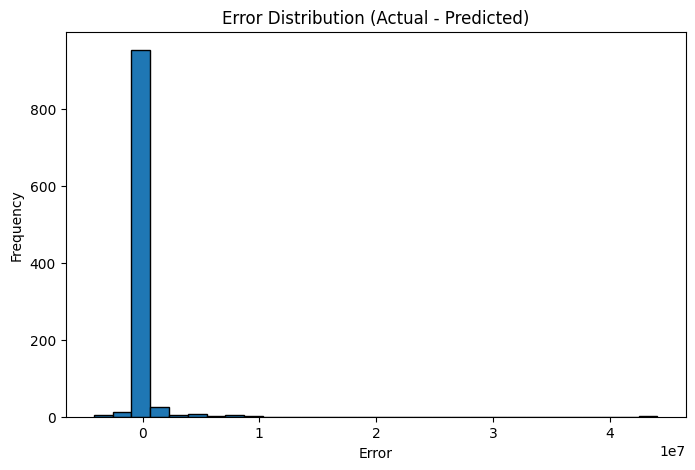

In [21]:
import matplotlib.pyplot as plt

errors = y_test_price_full - y_pred_price_rf_text

plt.figure(figsize=(8,5))
plt.hist(errors, bins=30, edgecolor='black')
plt.title("Error Distribution (Actual - Predicted)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


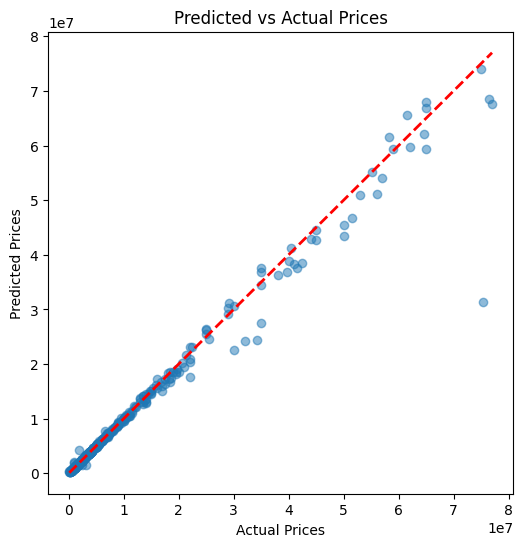

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_price_full, y_pred_price_rf_text, alpha=0.5)
plt.plot([y_test_price_full.min(), y_test_price_full.max()],
         [y_test_price_full.min(), y_test_price_full.max()],
         'r--', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual Prices")
plt.show()


Feature names: 835, Importances: 835


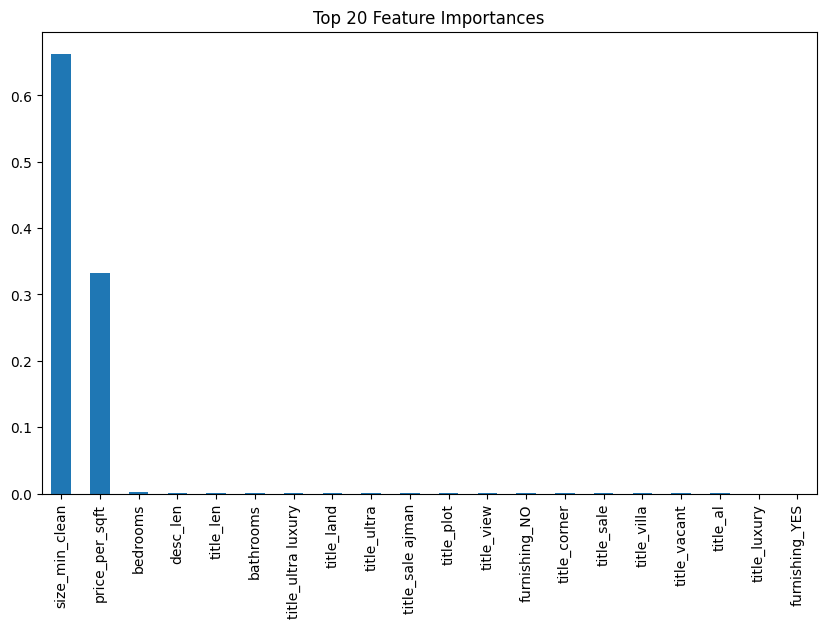

In [23]:
# ✅ Get feature names properly from the ColumnTransformer
def get_feature_names(column_transformer):
    output_features = []
    for name, trans, cols in column_transformer.transformers_:
        if name == 'remainder':
            continue

        if hasattr(trans, 'get_feature_names_out'):
            if isinstance(cols, list) and len(cols) == 1 and hasattr(trans, 'named_steps'):
                # For pipeline (like text -> tfidf)
                tfidf = trans.named_steps['tfidf']
                feats = tfidf.get_feature_names_out()
                feats = [f"{cols[0]}_{f}" for f in feats]  # prefix with column name
            else:
                feats = trans.get_feature_names_out(cols)
        else:
            feats = cols  # passthrough columns

        output_features.extend(feats)
    return output_features

# Get actual feature names from preprocessor
feature_names = get_feature_names(pipe_rf_text.named_steps['preprocessor'])

# Match with regressor importances
importances = pipe_rf_text.named_steps['regressor'].feature_importances_

print(f"Feature names: {len(feature_names)}, Importances: {len(importances)}")

# Build importance dataframe
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]

# Plot
plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title("Top 20 Feature Importances")
plt.show()


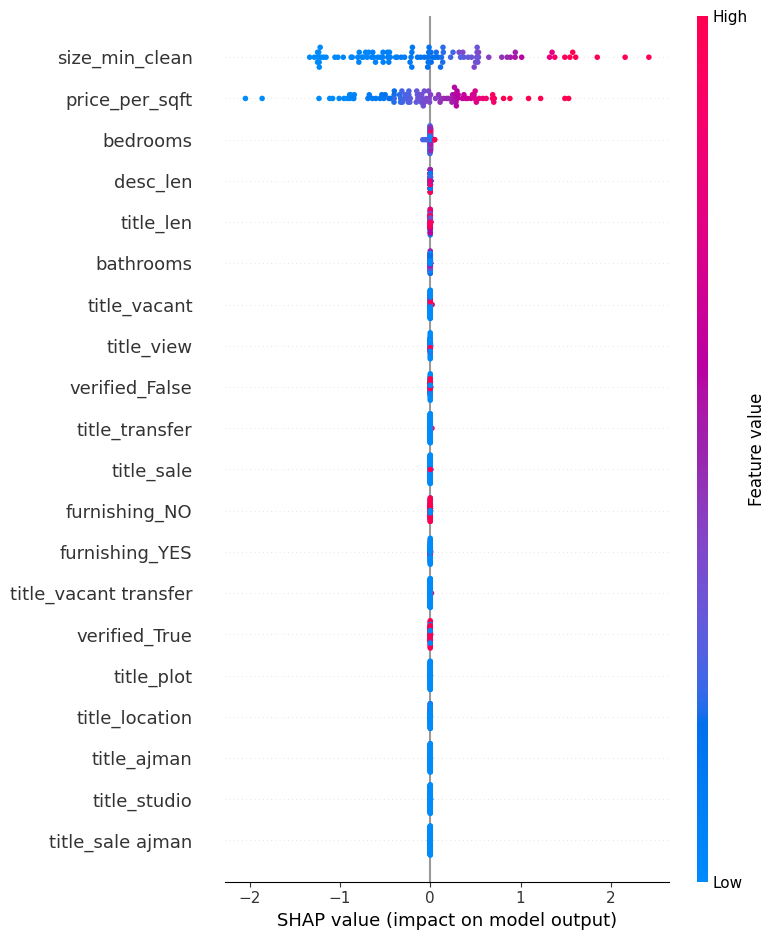

In [30]:
# Get only the trained regressor
regressor = pipe_rf_text.named_steps['regressor']

# Transform the data with preprocessing
X_train_transformed = preprocessor_with_text.transform(X_train_full[:100])
X_test_transformed  = preprocessor_with_text.transform(X_test_full[:100])

# Convert to dense numeric matrix
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed  = X_test_transformed.toarray()

# Build SHAP explainer on regressor
explainer = shap.TreeExplainer(regressor)
shap_values = explainer.shap_values(X_test_transformed)

# Plot with feature names
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)
